# RiskMetrics EWMA Volatility Forecasting

The goal here is to implement the RiskMetrics Exponentially Weighted Moving Average(EWMA) volatility model and discuss its ability to forecast future realized volatility.

Essentially I'd like to see whether placing greater weight on recent observations improves forecast accuracy relative to the historical volatility benchmark. See whether additional flexibility improves volatility forecasting performance from HVF.

# Introduction

In the previous notebook historical volatility forecastin model treated all observations within the rolling window equally. However, financial markets evolve continuously and recent market
information may be more relevant than older observations.

The RiskMetrics EWMA model addresses this problem by giving greater importance to recent returns while gradually discounting older information.

The RiskMetrics variance model (also known as exponential smoother) was first established in 1989, when Sir Dennis Weatherstone, the new chairman of J.P. Morgan, asked for a daily report measuring and explaining the risks of his firm. Nearly four years later in 1992, J.P. Morgan launched the RiskMetrics methodology to the marketplace, making the substantive research and analysis that satisfied Sir Dennis Weatherstone's request freely available to all market participants.

In 1998, as client demand for the group's risk management expertise exceeded the firm's internal risk management resources, the Corporate Risk Management Department was spun off from J.P. Morgan as RiskMetrics Group with 23 founding employees. The RiskMetrics technical document was revised in 1996. In 2001, it was revised again in Return to RiskMetrics. In 2006, a new method for modeling risk factor returns was introduced (RM2006). On 25 January 2008, RiskMetrics Group listed on the New York Stock Exchange (NYSE: RISK). In June 2010, RiskMetrics was acquired by MSCI for $1.55 billion.[1]



In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

plt.style.use("ggplot")

START = "2005-01-01"

In [2]:
#same loading of data as before 
spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] /
    spy["Close"].shift(1)
)

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

spy["target_20d"] = (
    spy["rv_20"]
    .shift(-20)
)

spy = spy.dropna()

[*********************100%***********************]  1 of 1 completed


# Understanding EWMA

Historical volatility forecasting model assumes that all observations contribute equally to future forecasts. However, market conditions can change rapidly. So recent information often contains more  value than information from several months ago.

The EWMA model captures this idea through exponential weighting.

The volatility recursion is:

$$\sigma^{2}_{t} = \lambda \sigma^{2}_{t-1} +(1-\lambda)r^2_{t-1} $$

where:

σ² = volatility variance

λ = decay parameter

r² = squared return

The model updates volatility continuously as new information arrives.

# Building the EWMA Model

Let's just see how it works

In [3]:
lam = 0.94

returns = spy["returns"].dropna()

ewma_var = [returns.var()]

for r in returns.iloc[1:]:

    ewma_var.append(
        lam * ewma_var[-1]
        +
        (1 - lam) * r**2
    )

spy = spy.iloc[:len(ewma_var)]

spy["ewma_vol"] = (
    np.sqrt(ewma_var)
    * np.sqrt(252)
)

# Visualizing EWMA Volatility 

Because EWMA responds continuously to new information, volatility estimates should react faster than historical averages.

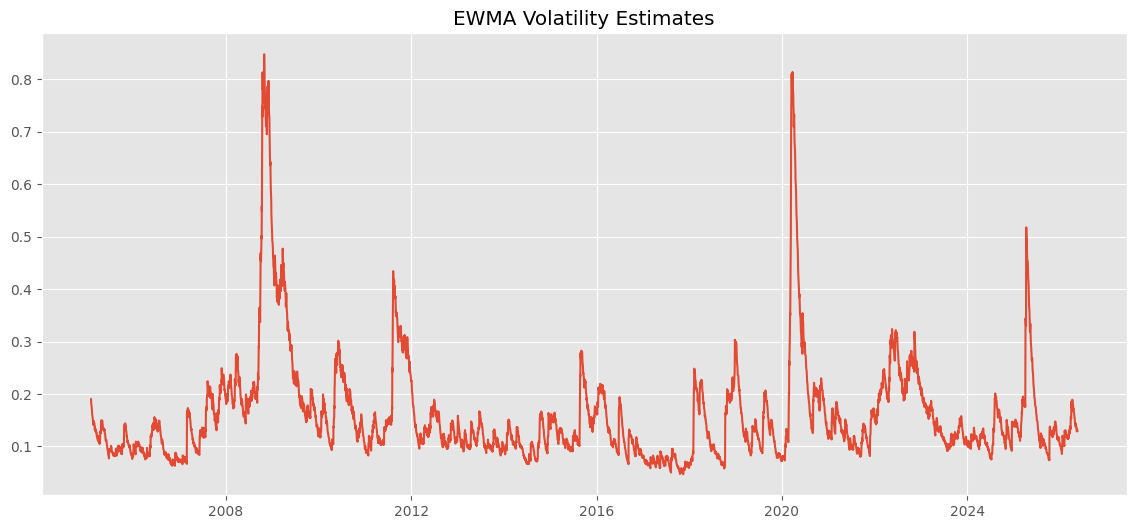

In [4]:
plt.figure(figsize=(14,6))

plt.plot(
    spy.index,
    spy["ewma_vol"]
)

plt.title(
    "EWMA Volatility Estimates"
)

plt.show()

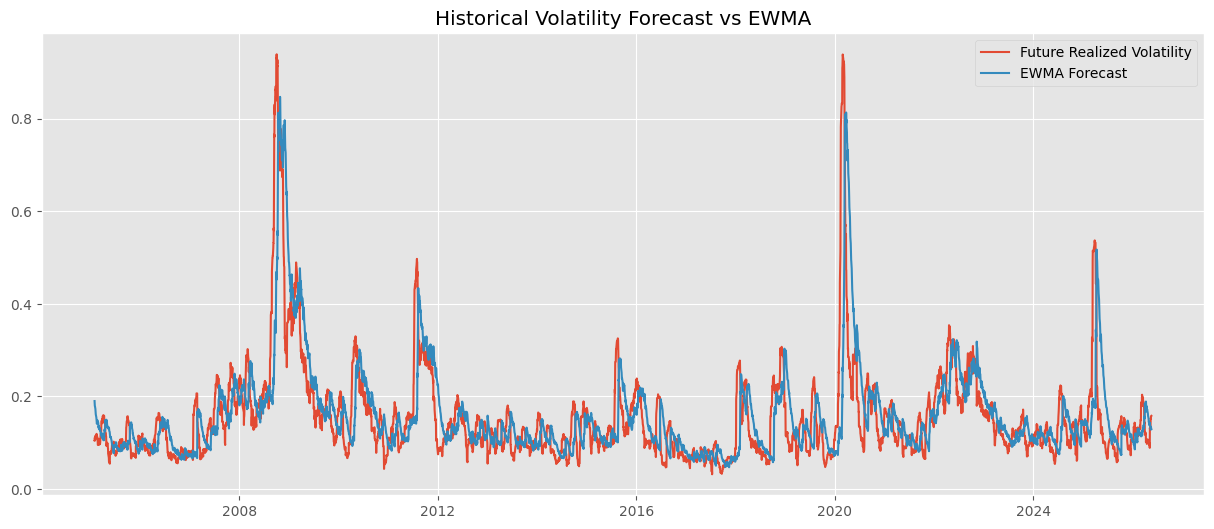

In [5]:
plt.figure(figsize=(15,6))

plt.plot(
    spy.index,
    spy["target_20d"],
    label="Future Realized Volatility"
)

plt.plot(
    spy.index,
    spy["ewma_vol"],
    label="EWMA Forecast"
)

plt.legend()

plt.title(
    "Historical Volatility Forecast vs EWMA"
)

plt.show()

## Comments

Volatility spikes remain visible for extended periods before gradually decaying. This looks like volatility clustering we talked about in Notebook 1.

# Experiment 1: Comparing the two volatility estimators

Historical volatility treats observations equally. EWMA places greater emphasis on recent observations.
We should compare the two to see the impact of this sort of recency bias.

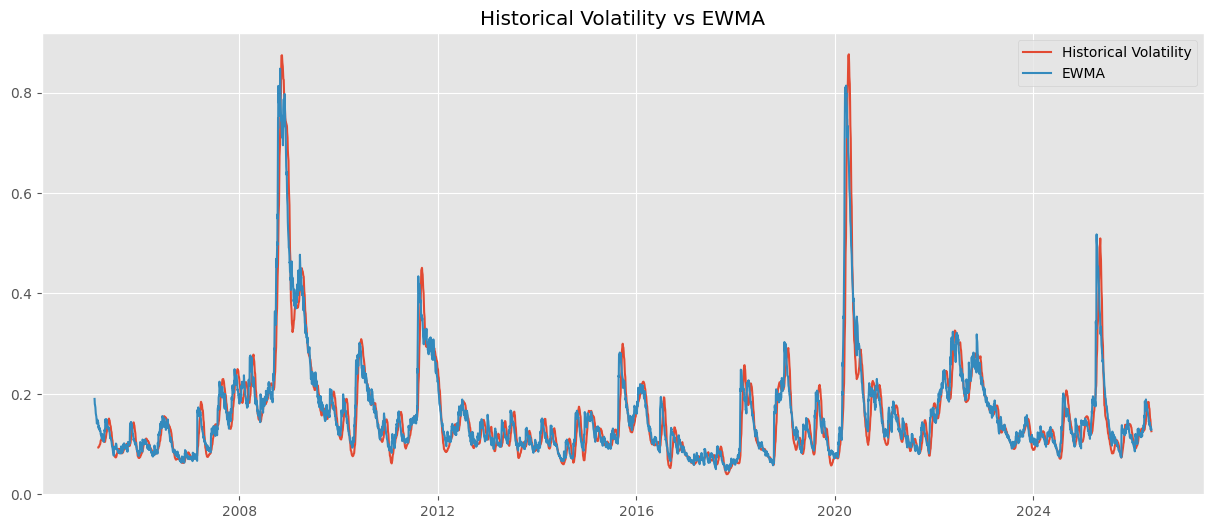

In [6]:
spy["hv_20"] = (
    spy["rv_20"]
    .rolling(20)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    spy.index,
    spy["hv_20"],
    label="Historical Volatility"
)

plt.plot(
    spy.index,
    spy["ewma_vol"],
    label="EWMA"
)

plt.legend()

plt.title(
    "Historical Volatility vs EWMA"
)

plt.show()

## Comments

EWMA reacts more quickly to changing market conditions.

Historical volatility responds more slowly because all observations within the rolling window receive equal weight. The difference becomes most visible during crisis periods. I shall look at this deeply in subsequent sections

# Experiment 2: Forecast Evaluation

As said before, a better model should produce smaller forecasting errors.
Let's compare EWMA forecasts with future realized volatility.

In [8]:
evaluation_df = spy[
    [
        "target_20d",
        "ewma_vol"
    ]
].dropna()

rmse = np.sqrt(
    mean_squared_error(
        evaluation_df["target_20d"],
        evaluation_df["ewma_vol"]
    )
)

mae = mean_absolute_error(
    evaluation_df["target_20d"],
    evaluation_df["ewma_vol"]
)

pd.DataFrame(
    {
        "Metric":["RMSE","MAE"],
        "Value":[rmse,mae]
    }
)

,Metric,Value
0,RMSE,0.088104
1,MAE,0.053040


## Comments

There is a clear improvement from RMSE=0.102388 MAE=0.059998 for HVF

# Experiment 3: Historical Volatility vs EWMA Forecasts

Now for the visual comparisons. Lets compare both forecasts against realized volatility.

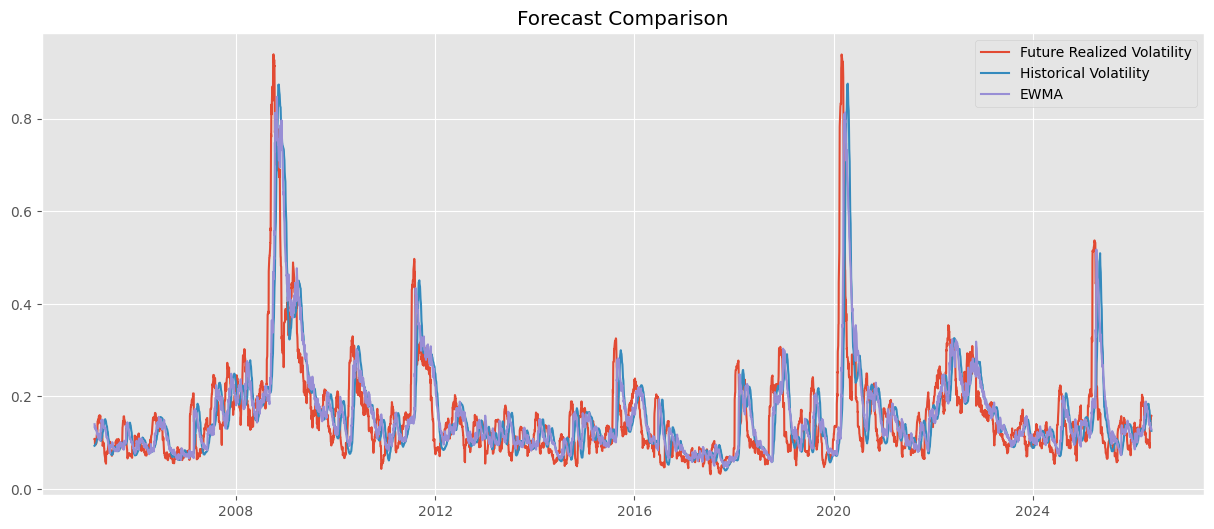

In [9]:
comparison = spy[
    [
        "target_20d",
        "hv_20",
        "ewma_vol"
    ]
].dropna()

plt.figure(figsize=(15,6))

plt.plot(
    comparison.index,
    comparison["target_20d"],
    label="Future Realized Volatility"
)

plt.plot(
    comparison.index,
    comparison["hv_20"],
    label="Historical Volatility"
)

plt.plot(
    comparison.index,
    comparison["ewma_vol"],
    label="EWMA"
)

plt.legend()

plt.title(
    "Forecast Comparison"
)

plt.show()

## Comments

It looks like EWMA responds in a better way to changing volatility. But I think looking at big crashes would be a better test for their performance. I'll do that towards the end of notebook. 

# Experiment 4: Decay Parameter Sensitivity

If lambda has a role to play, it controls the memory of the model.

Higher $\lambda$ values create smoother forecasts. Lower $\lambda$ values react more aggressively to recent information.

Selecting the right λ involves a trade off between stabilityand responsiveness.

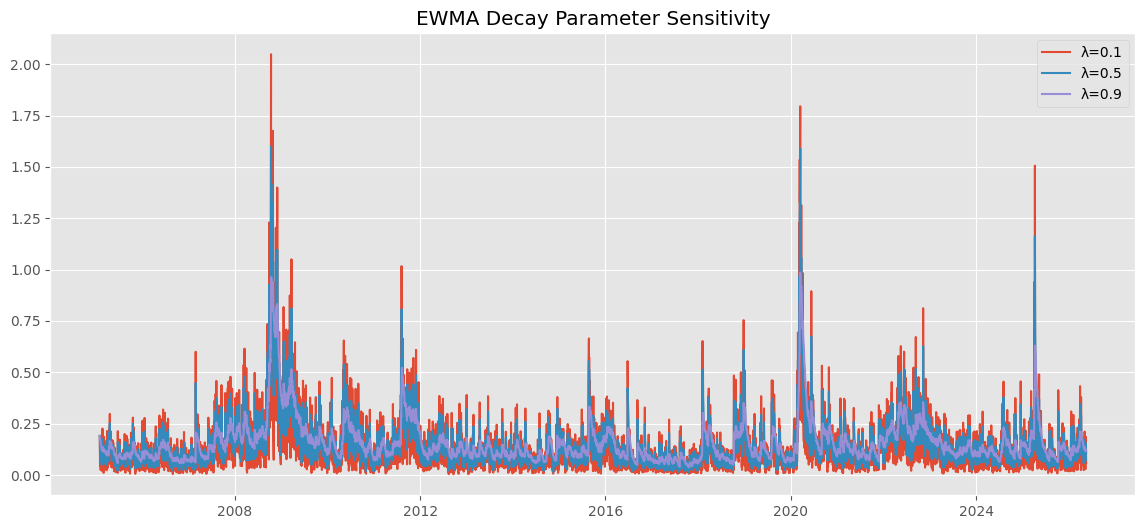

In [14]:
lambdas = [0.10,0.50,0.90]

plt.figure(figsize=(14,6))

for lam in lambdas:

    ewma_var = [returns.var()]

    for r in returns.iloc[1:]:

        ewma_var.append(
            lam * ewma_var[-1]
            +
            (1-lam) * r**2
        )

    plt.plot(
        spy.index,
        np.sqrt(ewma_var) * np.sqrt(252),
        label=f"λ={lam}"
    )

plt.legend()

plt.title(
    "EWMA Decay Parameter Sensitivity"
)

plt.show()

## Comments

Lower decay parameters react more aggressively to new information. Higher decay parameters generate smoother forecasts.

The commonly used RiskMetrics value of λ is 0.94. This is probably a compromise between these competing objectives.

# Case Study: EWMA During the COVID Crisis

Forecasting models are matter the most during crises. Periods of extreme volatility becomme a natural stress test for them. So I am trying to see if EWMA survives the crisis during COVID.

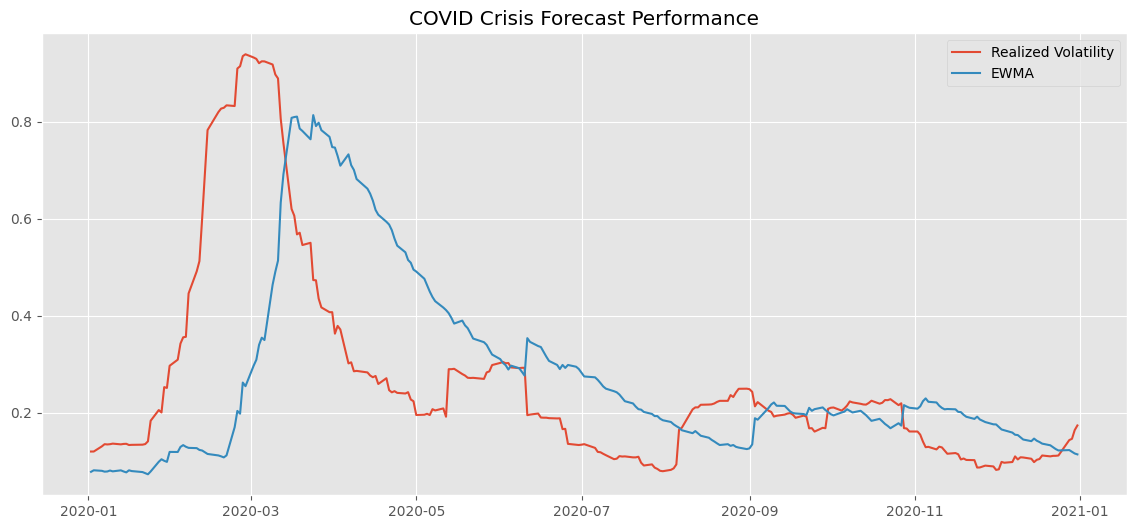

In [15]:
covid = comparison.loc[
    "2020-01-01":"2021-01-01"
]

plt.figure(figsize=(14,6))

plt.plot(
    covid.index,
    covid["target_20d"],
    label="Realized Volatility"
)

plt.plot(
    covid.index,
    covid["ewma_vol"],
    label="EWMA"
)

plt.legend()

plt.title(
    "COVID Crisis Forecast Performance"
)

plt.show()

## Comments

The crisis period highlights the strengths and weaknesses of EWMA.

The EWMA model reacts musch faster and nicely than historical volatility, yet the lag still exists during crisis. 

# Conclusion

The RiskMetrics EWMA model is better than the simple historical volatility model because it places greater weight on recent information. It captures volatility persistence effectively. Responds faster than historical volatility during crisis.

Its performance depends on the choice of decay parameter.

It is still quite simple but incorporates some features of volatilkity discussed in notebook 1.